# Time evolution — scalar diagnostics + Δσ_zz profile

Broadens the §10 time loop from `cerpa_single_step.ipynb`. Per timestep, records:

| symbol | meaning | shape |
|---|---|---|
| `t_yr` | model time | scalar |
| `tloc`, `xi_loc` | trench column, first isostatic column | scalars |
| `Fd_xT` | $F_D(x_T) = \int(\tau_{xx}-\tau_{zz})\,dz$ at the trench | scalar |
| `V_xT` | $V(x_T) = \int\tau_{xz}\,dz$ at the trench | scalar |
| `w_T` | $\mathrm{fs}(x_I) - \mathrm{fs}(x_T)$ — topographic recovery between the two columns | scalar |
| `delta_Fd` | $F_D(x_I) - F_D(x_T)$ — column difference of the deviatoric resultant | scalar |
| `delta_GPE` | $\mathrm{GPE}^*(x_I) - \mathrm{GPE}^*(x_T)$ where $\mathrm{GPE}^* = -\int\sigma_{zz}\,dz$ | scalar |
| `delta_sig_zz_z` | $\sigma_{zz}(x_I, z) - \sigma_{zz}(x_T, z)$ — full depth profile | (nz,) |

Conventions match the rest of the repo: x rightward, z downward, model mirrored along x at extraction so subduction is right-to-left.

Outputs are saved to `outputs/time_evolution_<MODEL>.npz`.

## 1. Setup & imports

In [17]:
import numpy as np
import glob
import natsort
import matplotlib.pyplot as plt
import pyvista as pv
import warnings, logging, gc
from pathlib import Path
from scipy.integrate import cumulative_trapezoid
from scipy.ndimage import gaussian_filter1d

pv.set_error_output_file(Path('/tmp/vtk_errors.log'))
logging.getLogger('pyvista').setLevel(logging.CRITICAL)
logging.getLogger().setLevel(logging.CRITICAL)
warnings.filterwarnings('ignore', message='The VTK reader .*vtkXMLPUnstructuredGridReader.*')

plt.rcParams.update({'mathtext.fontset': 'cm', 'font.family': 'serif'})

## 2. Configuration

Same setup conventions as the other Cerpa notebooks. `MIRROR_X = True` mirrors the model along x so subduction matches MDOODZ orientation.

In [18]:
DATA_ROOT = '/Users/DSAND/DATA/numerical_models/OUTPUTS/'

MODELS = {
    #'STD': dict(folder='STD_RefModel', modname='subduction_with_LM'),
    'WAL': dict(folder='WAL_RefModel', modname='subduction_with_LM'),
}

MODEL_KEY = 'WAL'

DX        = 200.0
Z_MAX     = 100_000.0
Y_SURFACE = 2_900_000.0

# Mirror flag and derived directional constants
MIRROR_X        = True
SUBDUCTING_SIDE = 'right' if MIRROR_X else 'left'
SEAWARD_SIGN    = +1     if MIRROR_X else -1

# Isostatic-column picker parameters
BUFFER_KM    = 30           # skip this much of the bend right next to the trench
WINDOW_KM    = 500          # search window seaward of the trench
REGIONAL_REF_KM = 500       # offset of the 'regional' reference column from the trench

fbase   = DATA_ROOT + MODELS[MODEL_KEY]['folder'] + '/'
modname = MODELS[MODEL_KEY]['modname']
pvtu_files = natsort.natsorted(glob.glob(fbase + modname + '*.pvtu'))
print(f"Model {MODEL_KEY!r}: {len(pvtu_files)} PVTU files in {fbase}")
print(f"MIRROR_X = {MIRROR_X}  ->  SUBDUCTING_SIDE = {SUBDUCTING_SIDE!r}, SEAWARD_SIGN = {SEAWARD_SIGN:+d}")

Model 'WAL': 41 PVTU files in /Users/DSAND/DATA/numerical_models/OUTPUTS/WAL_RefModel/
MIRROR_X = True  ->  SUBDUCTING_SIDE = 'right', SEAWARD_SIGN = +1


## 3. Helpers

- `get_field(name)` — reshapes a sampled VTK array onto the regular grid.
- `mirror_fields_in_x(...)` — applies the x-mirror with sign flips on the off-diagonal stress and x-velocity.
- `pick_trench_3step(...)` — same picker as the other notebooks (pressure → velocity → directional pressure).
- `find_first_isostatic_column(...)` — walks seaward from the trench and returns the index of the first column whose free-surface elevation has recovered to the regional reference.

In [19]:
def get_field(name):
    f = interp[name].reshape((nx_pv, nz_pv), order='F')
    f[~valid] = np.nan
    return f.T  # (z, x)


def mirror_fields_in_x(p, txx, tzz, txz, T, fs, vx, vz):
    # Mirror all 2D fields along x so subduction matches MDOODZ orientation.
    # Under x -> -x: scalars/diagonals flip in space only; off-diagonal stress
    # and vx pick up an additional sign flip.
    flip = lambda a: np.flip(a, axis=1)
    return (flip(p), flip(txx), flip(tzz), -flip(txz),
            flip(T), flip(fs), -flip(vx), flip(vz))

In [20]:
def pick_trench_3step(x, z, p, vx,
        p_depth_m=0.0, vx_depth_m=5_000.0,
        Wp1_km=800.0, Wv_km=800.0, Wp3_km=300.0,
        expected_offset_km=50.0, smooth_km=20.0,
        subducting_side='left'):
    iz_p  = 0 if p_depth_m == 0.0 else int(np.argmin(np.abs(z - p_depth_m)))
    iz_vx = int(np.argmin(np.abs(z - vx_depth_m)))
    p_row, vx_row = p[iz_p, :].copy(), vx[iz_vx, :].copy()

    j0 = int(np.nanargmin(p_row));  x_p0 = float(x[j0])

    Wv = Wv_km * 1000.0
    in_v = (x >= x_p0 - Wv) & (x <= x_p0 + Wv)
    x_vw, vx_vw = x[in_v], vx_row[in_v]
    dx = np.median(np.diff(x))
    k = max(1, int((smooth_km*1000.0)/dx)); k += (k%2 == 0)
    vx_s = np.convolve(vx_vw, np.ones(k)/k, mode='same')
    s = np.sign(vx_s); s[s == 0] = np.nan
    cross = np.where(np.isfinite(s[:-1]) & np.isfinite(s[1:]) & (s[:-1]*s[1:] < 0))[0]
    if cross.size == 0:
        x_v = float(x_vw[int(np.nanargmin(np.abs(vx_s)))])
    else:
        xc = []
        for ii in cross:
            x1, x2 = x_vw[ii], x_vw[ii+1]
            v1, v2 = vx_s[ii], vx_s[ii+1]
            xc.append(x1 - v1 * (x2 - x1) / (v2 - v1))
        xc = np.array(xc)
        # Pick velocity zero-crossing on the subducting-plate side
        # (rightmost when slab descends right, leftmost when it descends left).
        x_v = float(np.max(xc) if subducting_side == 'right' else np.min(xc))

    Wp3 = Wp3_km * 1000.0
    expected_offset = expected_offset_km * 1000.0
    if subducting_side == 'left':
        mask = (x < x_v) & (x >= x_v - Wp3)
        x_expected = x_v - expected_offset
    else:
        mask = (x > x_v) & (x <= x_v + Wp3)
        x_expected = x_v + expected_offset
    xw, pw = x[mask], p_row[mask]
    good = np.isfinite(pw); xw, pw = xw[good], pw[good]
    is_min = (pw[1:-1] < pw[:-2]) & (pw[1:-1] < pw[2:])
    idx = np.where(is_min)[0] + 1
    if idx.size == 0:
        trench_x = float(xw[int(np.argmin(pw))])
    else:
        j = idx[np.argmin(np.abs(xw[idx] - x_expected))]
        trench_x = float(xw[j])

    return trench_x, dict(x_p0=x_p0, x_v=x_v)


In [21]:
def find_first_isostatic_column(x, fs_top, tloc, tindx, DX,
                                 buffer_km=30, window_km=500,
                                 regional_ref_km=500, seaward_sign=+1):
    # Walk seaward of the trench (with a buffer) and return the first index
    # where the free-surface elevation has recovered to the regional reference
    # taken `regional_ref_km` seaward of the trench.
    i_far = int(np.argmin(np.abs(x - (tloc + seaward_sign * regional_ref_km * 1000.0))))
    target = float(fs_top[i_far])

    buffer_grid = int(buffer_km * 1000.0 / DX)
    window_grid = int(window_km * 1000.0 / DX)
    i_start = max(0, min(len(x)-1, tindx + seaward_sign * buffer_grid))
    i_end   = max(0, min(len(x)-1, tindx + seaward_sign * window_grid))
    step    = int(np.sign(seaward_sign)) or +1

    for i in range(i_start, i_end, step):
        if fs_top[i] >= target:
            return i, i_far
    return i_end, i_far

## 4. Time loop

For each PVTU snapshot: load → mirror → pick trench → find first isostatic column → compute the column quantities → record scalars + the Δσ_zz depth profile.

In [23]:
#pvtu_files[::2]

In [30]:
SECONDS_PER_YEAR = 31_557_600.0

# Records (one entry per snapshot)
records = dict(
    snapshot=[], t_yr=[], tloc=[], xi_loc=[],
    Fd_xT=[], V_xT=[], w_T=[], delta_Fd=[], delta_GPE=[],
)
delta_sig_zz_z_list = []   # one (nz,) array per snapshot
z_axis = None              # populated on the first snapshot

for i, ff in enumerate(pvtu_files[::1]):
    if i == 0:
        # Skip the initial-condition snapshot (often empty or trivial)
        continue

    vtk_data = pv.read(ff)
    vtk_data.point_data['p']   = vtk_data['NormalSP::Pressure']
    vtk_data.point_data['txx'] = vtk_data['NormalSP::Stress'][:, 0]
    vtk_data.point_data['tzz'] = vtk_data['NormalSP::Stress'][:, 4]
    vtk_data.point_data['txz'] = -vtk_data['NormalSP::Stress'][:, 1]   # z-down sign flip
    vtk_data.point_data['T']   = vtk_data['NormalSP::Temperature']
    vtk_data.point_data['fs']  = vtk_data['NormalSP::FreeSurface']
    vel = vtk_data['NormalSP::Velocity'] / 3.17098e-10
    vtk_data.point_data['vx']  = vel[:, 0]
    vtk_data.point_data['vy']  = vel[:, 1]

    t_yr = float(np.asarray(vtk_data['NormalSP::Time']).flat[0]) / SECONDS_PER_YEAR

    # Build grid
    x_min, x_max, _, _, _, _ = vtk_data.bounds
    nx = int((x_max - x_min) / DX); nz = int(Z_MAX / DX)
    x = x_min + (np.arange(nx) + 0.5) * DX
    z = (np.arange(nz) + 0.5) * DX
    X, Z = np.meshgrid(x, z, indexing='xy')
    Y = Y_SURFACE - Z
    grid = pv.StructuredGrid(X.T, Y.T, np.zeros_like(X.T))
    interp = grid.sample(vtk_data)
    nx_pv, nz_pv, _ = interp.dimensions
    valid = interp['vtkValidPointMask'].reshape((nx_pv, nz_pv), order='F').astype(bool)

    # Extract
    p   = get_field('p')
    txx = get_field('txx')
    tzz = get_field('tzz')
    txz = get_field('txz')
    T   = get_field('T')
    fs  = get_field('fs')
    vx  = get_field('vx')
    vz  = -get_field('vy')

    # Mirror
    if MIRROR_X:
        p, txx, tzz, txz, T, fs, vx, vz = mirror_fields_in_x(p, txx, tzz, txz, T, fs, vx, vz)

    if z_axis is None:
        z_axis = z.copy()

    # Pick trench
    try:
        tloc, _ = pick_trench_3step(
            x, z, p, vx,
            vx_depth_m=2000, Wp1_km=800, Wv_km=800, Wp3_km=500,
            smooth_km=30, subducting_side=SUBDUCTING_SIDE,
        )
    except Exception as e:
        print(f'  [{i}] picker failed: {e}; skipping')
        continue
    tindx = int(np.argmin(np.abs(x - tloc)))

    # First isostatic column
    xi_indx, _ = find_first_isostatic_column(
        x, fs[0, :], tloc, tindx, DX,
        buffer_km=BUFFER_KM, window_km=WINDOW_KM,
        regional_ref_km=REGIONAL_REF_KM, seaward_sign=SEAWARD_SIGN,
    )
    xi_loc = float(x[xi_indx])

    # Column quantities
    Fd_x   = np.trapz(txx - tzz, z, axis=0)            # (nx,)
    V_x    = np.trapz(txz, z, axis=0)                  # (nx,)
    GPE_x  = -np.trapz(-p + tzz, z, axis=0)            # (nx,)  GPE* = -int sigma_zz dz
    sig_zz = -p + tzz                                  # (nz, nx)

    # Scalars
    Fd_xT     = float(Fd_x[tindx])
    V_xT      = float(V_x[tindx])
    w_T       = float(fs[0, xi_indx] - fs[0, tindx])
    delta_Fd  = float(Fd_x[xi_indx]  - Fd_x[tindx])
    delta_GPE = float(GPE_x[xi_indx] - GPE_x[tindx])

    # Δσ_zz depth profile
    delta_sig_zz_z = sig_zz[:, xi_indx] - sig_zz[:, tindx]   # (nz,)

    # Append
    records['snapshot'].append(i)
    records['t_yr'].append(t_yr)
    records['tloc'].append(tloc)
    records['xi_loc'].append(xi_loc)
    records['Fd_xT'].append(Fd_xT)
    records['V_xT'].append(V_xT)
    records['w_T'].append(w_T)
    records['delta_Fd'].append(delta_Fd)
    records['delta_GPE'].append(delta_GPE)
    delta_sig_zz_z_list.append(delta_sig_zz_z)

    # Cleanup
    del vtk_data, grid, interp, X, Y, Z, p, txx, tzz, txz, T, fs, vx, vz
    if i % 5 == 0:
        gc.collect()

# Convert to arrays
for k in records:
    records[k] = np.asarray(records[k])
delta_sig_zz_zt = np.vstack(delta_sig_zz_z_list)   # shape (n_snapshots, nz)

print(f'\n[{MODEL_KEY}] processed {len(records["snapshot"])} snapshots')
print(f'    t = {records["t_yr"].min()/1e6:6.2f} -> {records["t_yr"].max()/1e6:6.2f} Myr')
print(f'    F_D(x_T)   = {records["Fd_xT"].min()*1e-12:+6.2f}  to {records["Fd_xT"].max()*1e-12:+6.2f} TN/m')
print(f'    V(x_T)     = {records["V_xT"].min()*1e-12:+6.2f}  to {records["V_xT"].max()*1e-12:+6.2f} TN/m')
print(f'    w_T        = {records["w_T"].min():+6.0f}  to {records["w_T"].max():+6.0f}  m')
print(f'    Δ F_D      = {records["delta_Fd"].min()*1e-12:+6.2f}  to {records["delta_Fd"].max()*1e-12:+6.2f} TN/m')
print(f'    Δ GPE*     = {records["delta_GPE"].min()*1e-12:+6.2f}  to {records["delta_GPE"].max()*1e-12:+6.2f} TN/m')


[WAL] processed 40 snapshots
    t =   2.01 ->  79.95 Myr
    F_D(x_T)   =  -4.14  to  +0.29 TN/m
    V(x_T)     =  -2.09  to  -0.35 TN/m
    w_T        =  +1364  to  +2394  m
    Δ F_D      =  +1.49  to  +2.91 TN/m
    Δ GPE*     =  +1.57  to  +3.00 TN/m


## 5. Persist to npz

In [31]:
outputs_dir = Path('outputs'); outputs_dir.mkdir(exist_ok=True)
npz_path = outputs_dir / f'time_evolution_{MODEL_KEY}.npz'
np.savez(npz_path, z=z_axis, delta_sig_zz_zt=delta_sig_zz_zt, **records)
print(f'saved -> {npz_path}')

saved -> outputs/time_evolution_WAL.npz


## 6. Time-series plots

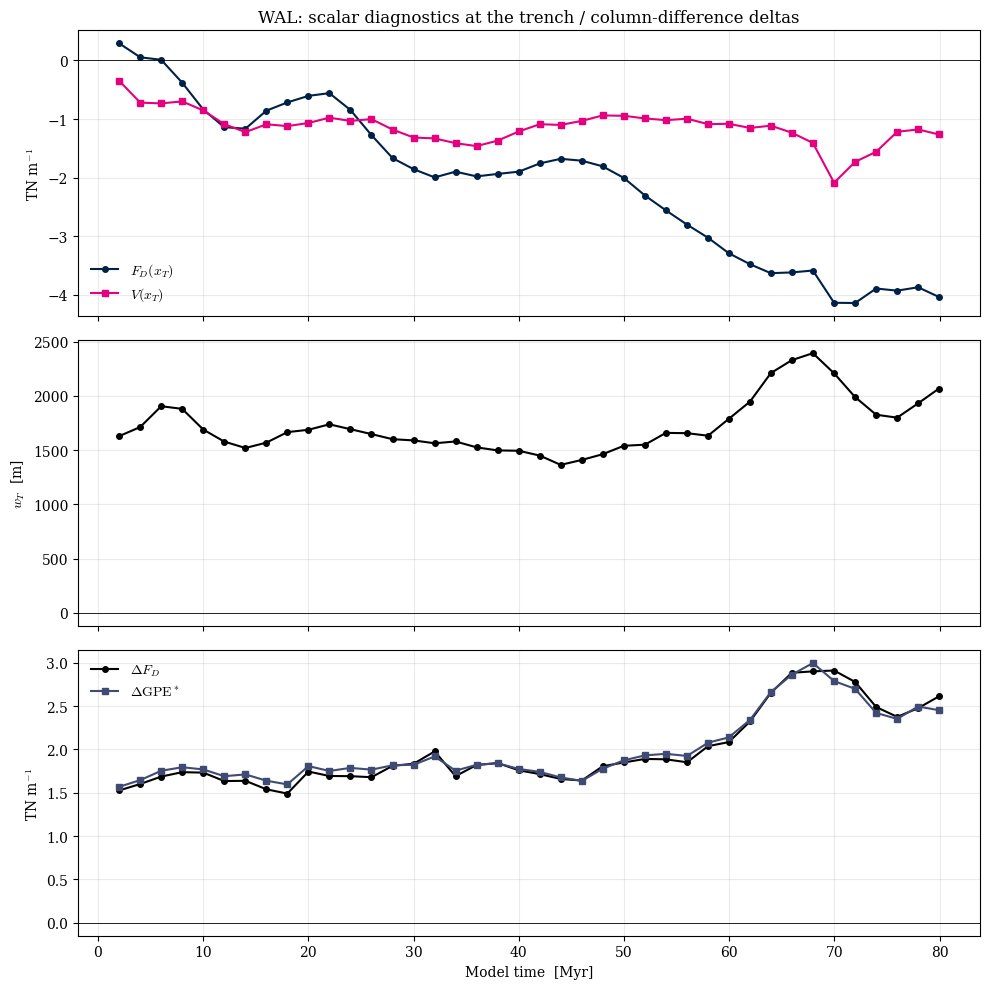

In [32]:
t_Myr = records['t_yr'] / 1e6

fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# (a) F_D and V at the trench
axs[0].plot(t_Myr, records['Fd_xT'] * 1e-12, '-o', color='#002147', ms=4, lw=1.5,
            label=r'$F_D(x_T)$')
axs[0].plot(t_Myr, records['V_xT']  * 1e-12, '-s', color='#E5007D', ms=4, lw=1.5,
            label=r'$V(x_T)$')
axs[0].axhline(0, color='k', lw=0.6)
axs[0].set_ylabel(r'TN m$^{-1}$')
axs[0].legend(frameon=False, loc='best')
axs[0].grid(alpha=0.25)
axs[0].set_title(f'{MODEL_KEY}: scalar diagnostics at the trench / column-difference deltas')

# (b) trench depression
axs[1].plot(t_Myr, records['w_T'], '-o', color='k', ms=4, lw=1.5)
axs[1].axhline(0, color='k', lw=0.6)
axs[1].set_ylabel(r'$w_T$  [m]')
axs[1].grid(alpha=0.25)

# (c) deltas (column differences x_I - x_T)
axs[2].plot(t_Myr, records['delta_Fd']  * 1e-12, '-o', color='k',       ms=4, lw=1.5,
            label=r'$\Delta F_D$')
axs[2].plot(t_Myr, records['delta_GPE'] * 1e-12, '-s', color='#404B74', ms=4, lw=1.5,
            label=r'$\Delta \mathrm{GPE}^*$')
axs[2].axhline(0, color='k', lw=0.6)
axs[2].set_ylabel(r'TN m$^{-1}$')
axs[2].set_xlabel('Model time  [Myr]')
axs[2].legend(frameon=False, loc='best')
axs[2].grid(alpha=0.25)

fig.tight_layout()
figures_dir = Path('figures'); figures_dir.mkdir(exist_ok=True)
fig.savefig(figures_dir / f'time_evolution_scalars_{MODEL_KEY}.png',
            bbox_inches='tight', dpi=200)
plt.show()

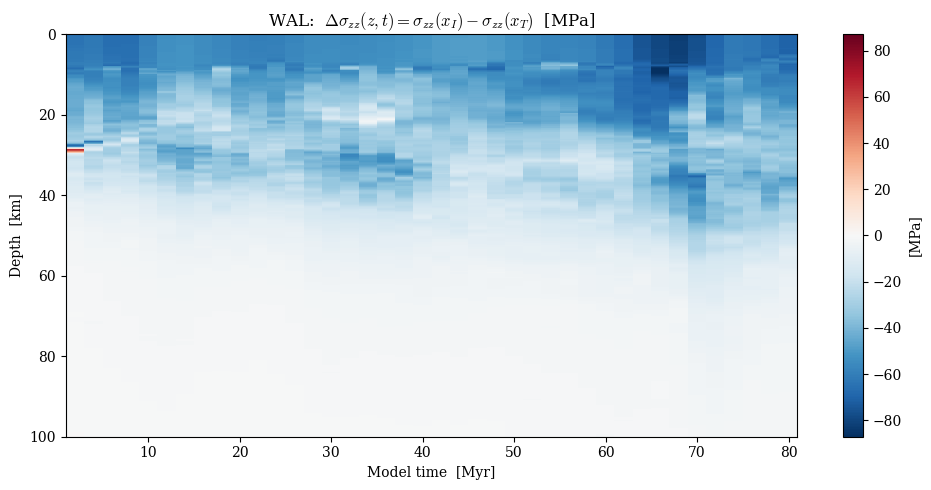

In [33]:
# Δσ_zz(z, t) — depth-by-time heat map
fig, ax = plt.subplots(figsize=(10, 5))
vmax = np.nanmax(np.abs(delta_sig_zz_zt)) * 1e-6
im = ax.pcolormesh(t_Myr, z_axis * 1e-3, delta_sig_zz_zt.T * 1e-6,
                   shading='auto', cmap='RdBu_r', vmin=-vmax, vmax=+vmax)
ax.invert_yaxis()
ax.set_xlabel('Model time  [Myr]')
ax.set_ylabel('Depth  [km]')
ax.set_title(rf'{MODEL_KEY}:  $\Delta \sigma_{{zz}}(z, t) = \sigma_{{zz}}(x_I) - \sigma_{{zz}}(x_T)$  [MPa]')
fig.colorbar(im, ax=ax, label='[MPa]')
fig.tight_layout()
fig.savefig(figures_dir / f'time_evolution_dsigzz_{MODEL_KEY}.png',
            bbox_inches='tight', dpi=200)
plt.show()